In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import pandas as pd
import os

df = pd.read_csv(os.path.join("/content/drive/MyDrive/Data", 'train.csv'))

print(df.head())
print(df.columns)
print(df.shape)

         image_id  label
0  1000015157.jpg      0
1  1000201771.jpg      3
2   100042118.jpg      1
3  1000723321.jpg      1
4  1000812911.jpg      3
Index(['image_id', 'label'], dtype='object')
(21397, 2)


In [8]:
from PIL import Image
import numpy as np
import os


image_folder = "/content/drive/MyDrive/Data/train_images - Copy - Copy"


IMG_SIZE = 128

X = []

image_files = os.listdir(image_folder)

print("Number of images:", len(image_files))

for file in image_files:

    if file.lower().endswith((".jpg", ".jpeg", ".png")):

        image_path = os.path.join(image_folder, file)

        image = Image.open(image_path)


        image = image.convert("RGB")


        image = image.resize((IMG_SIZE, IMG_SIZE))


        image = np.array(image)

        X.append(image)


X = np.array(X)

print("Resized image shape:", X.shape)

Number of images: 897
Resized image shape: (896, 128, 128, 3)


In [9]:

X = X.astype("float32") / 255.0

print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [10]:
import pandas as pd
import os
import numpy as np


csv_path = "/content/drive/MyDrive/Data/train.csv"
df = pd.read_csv(csv_path)


df["image_id"] = df["image_id"].astype(str)


image_files = [
    file for file in os.listdir(image_folder)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
]


label_dict = dict(zip(df["image_id"], df["label"]))


y = np.array([label_dict[file] for file in image_files])

print("Number of images:", len(X))
print("Number of labels:", len(y))

print("\nFirst 10 labels:")
print(y[:10])

print("\nUnique labels:")
print(np.unique(y))

Number of images: 896
Number of labels: 896

First 10 labels:
[3 1 3 3 3 1 2 3 3 3]

Unique labels:
[0 1 2 3 4]


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)

print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

Training images: (716, 128, 128, 3)
Training labels: (716,)
Testing images: (180, 128, 128, 3)
Testing labels: (180,)


Number of images in each class:
0     44
1    107
2    101
3    536
4    108
Name: count, dtype: int64


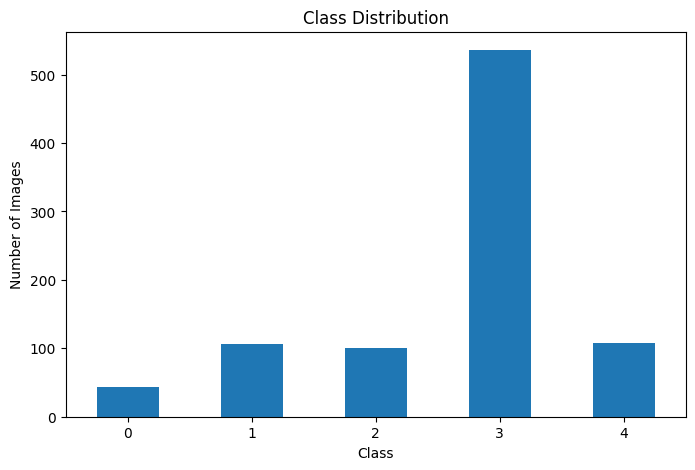

In [12]:
import matplotlib.pyplot as plt

class_counts = pd.Series(y).value_counts().sort_index()

print("Number of images in each class:")
print(class_counts)
plt.figure(figsize=(8, 5))

class_counts.plot(kind="bar")

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.xticks(rotation=0)

plt.show()

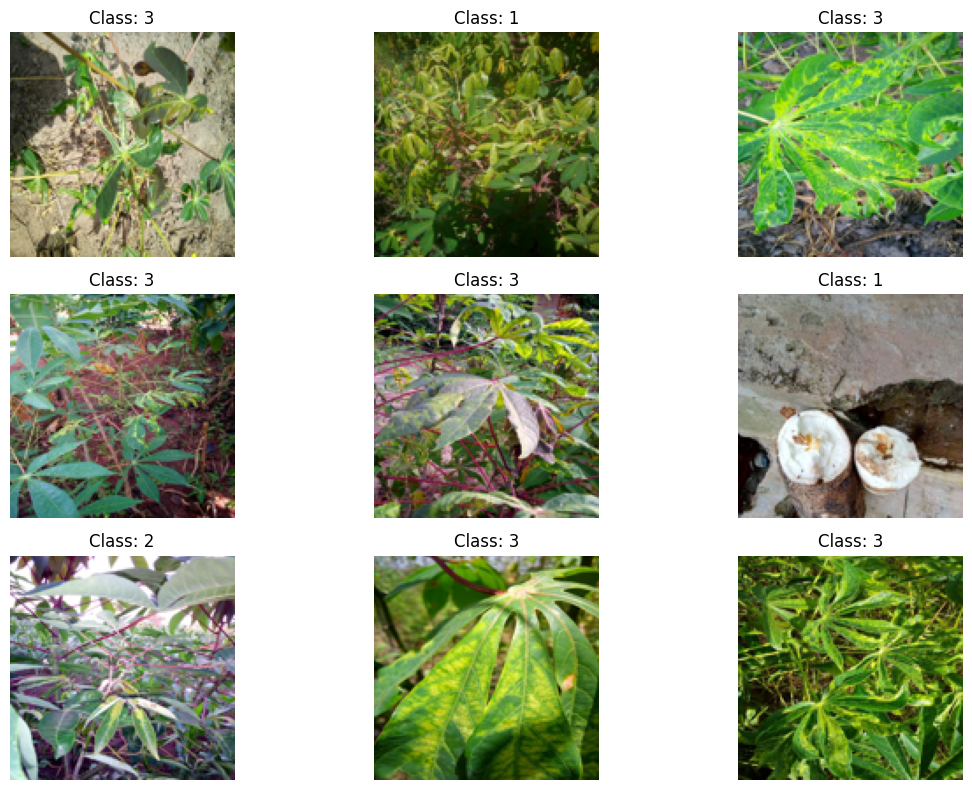

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)

    plt.imshow(X[i])

    plt.title(f"Class: {y[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:

class_counts = pd.Series(y).value_counts().sort_index()

print("Images in each class:")
print(class_counts)

max_count = class_counts.max()
min_count = class_counts.min()

print("\nLargest class:", max_count)
print("Smallest class:", min_count)
print("Difference:", max_count - min_count)

Images in each class:
0     44
1    107
2    101
3    536
4    108
Name: count, dtype: int64

Largest class: 536
Smallest class: 44
Difference: 492


In [15]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


num_classes = len(np.unique(y))

print("Number of classes:", num_classes)

model = Sequential([


    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),


    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),


    Flatten(),


    Dense(128, activation='relu'),

    Dropout(0.5),


    Dense(num_classes, activation='softmax')
])


model.summary()

Number of classes: 5


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [17]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.5647 - loss: 1.2906 - val_accuracy: 0.5972 - val_loss: 1.2403
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.5979 - loss: 1.2157 - val_accuracy: 0.5972 - val_loss: 1.2226
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 992ms/step - accuracy: 0.5979 - loss: 1.1998 - val_accuracy: 0.5972 - val_loss: 1.2347
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.6014 - loss: 1.1514 - val_accuracy: 0.5972 - val_loss: 1.2203
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.6101 - loss: 1.1252 - val_accuracy: 0.6111 - val_loss: 1.1655
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.6259 - loss: 1.0500 - val_accuracy: 0.6111 - val_loss: 1.1362
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 992ms/step - accuracy: 0.6381 - loss: 1.0334 - val_accuracy: 0.6111 - val_loss: 1.1101
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 998ms/step - accuracy: 0.6538 - loss: 0.9643 - val_accuracy: 0.6181 - 

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)
f1 = f1_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 258ms/step
Accuracy : 0.6166666666666667
Precision: 0.4402857142857142
Recall   : 0.6166666666666667
F1-score : 0.4848736069584127


Confusion Matrix:
[[  0   2   0   7   0]
 [  0   3   0  18   0]
 [  0   0   0  20   0]
 [  0   0   0 108   0]
 [  0   0   0  22   0]]


<Figure size 800x800 with 0 Axes>

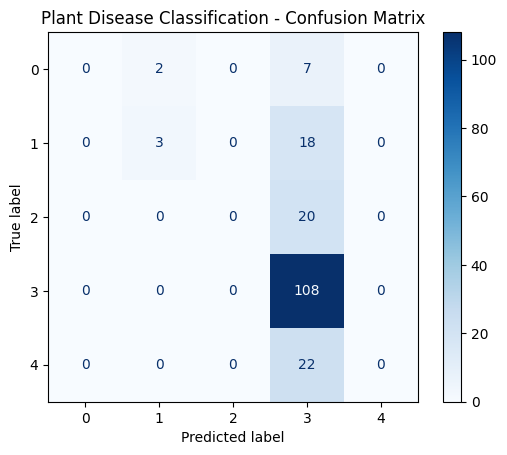

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(8, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues", values_format="d")

plt.title("Plant Disease Classification - Confusion Matrix")
plt.show()

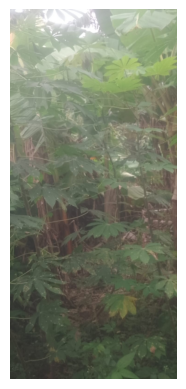

Input shape: (1, 128, 128, 3)


In [20]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

image_path = "/content/test_image.jpg.jpeg"

image = Image.open(image_path)

plt.imshow(image)
plt.axis("off")
plt.show()

image = image.convert("RGB")

image = image.resize((128, 128))

image_array = np.array(image)
image_array = image_array.astype("float32") / 255.0
image_array = np.expand_dims(image_array, axis=0)
print("Input shape:", image_array.shape)

In [21]:
prediction = model.predict(image_array)

predicted_class = np.argmax(prediction[0])

confidence = np.max(prediction[0]) * 100

print("Predicted class:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
Predicted class: 3
Confidence: 37.28 %


In [28]:
import os
import json
import pandas as pd

data_path = "/content/drive/MyDrive/Data"

mapping_file = [
    f for f in os.listdir(data_path)
    if "label_num_to_disease" in f.lower()
][0]

mapping_path = os.path.join(data_path, mapping_file)

if mapping_path.lower().endswith(".json"):

    with open(mapping_path, "r") as f:
        mapping = json.load(f)

    disease = mapping.get(str(predicted_class))

    if disease is None:
        disease = mapping.get(predicted_class, "Unknown")

else:

    df = pd.read_csv(mapping_path)

    disease = None

    for column in df.columns:
        matches = df[df[column].astype(str).str.strip() == str(predicted_class)]

        if len(matches) > 0:
            other_columns = [c for c in df.columns if c != column]

            if other_columns:
                disease = matches.iloc[0][other_columns[0]]
                break

    if disease is None:
        disease = "Unknown"

print("Predicted Class:", predicted_class)
print("Disease:", disease)
print("Confidence:", round(confidence, 2), "%")

Predicted Class: 3
Disease: Cassava Mosaic Disease (CMD)
Confidence: 37.28 %
